# Data Load And Analysis

In [25]:
# Everytime reload the notebook, reload the modules
%load_ext autoreload
%autoreload 2

# Data load and split

import os
import glob
import random
import numpy as np

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Load npy files from road_track dataset
obs_ae_dir = "data/road_track/obs_ae"
eval_real_dir = "data/road_track/eval_real"

# Get all npy files from obs_ae directory (training data)
all_npy_files = sorted(glob.glob(os.path.join(obs_ae_dir, "*.npy")))
print(f"Total files in obs_ae: {len(all_npy_files)}")

# Get all eval_real files
eval_real_files = sorted(glob.glob(os.path.join(eval_real_dir, "*.npy")))
print(f"Total files in eval_real: {len(eval_real_files)}")

# Split eval_real files: 70% for training, 30% for validation (to match data distribution)
random.shuffle(eval_real_files)
eval_real_train_split = int(0.7 * len(eval_real_files))
eval_real_train_files = eval_real_files[:eval_real_train_split]
eval_real_val_files = eval_real_files[eval_real_train_split:]

print(f"eval_real split: {len(eval_real_train_files)} for train, {len(eval_real_val_files)} for val")

# Reduce obs_ae data to balance with eval_real data
# Target ratio: obs_ae to eval_real should be around 3:1 to 5:1
# After replication, eval_real_train will be around 400-500, so limit obs_ae to 2000-3000
max_obs_ae_files = max(4000, len(eval_real_train_files) * 4)  # 4x eval_real for better balance
if len(all_npy_files) > max_obs_ae_files:
    random.shuffle(all_npy_files)
    all_npy_files = all_npy_files[:max_obs_ae_files]
    print(f"Sampled {max_obs_ae_files} files from obs_ae to balance with eval_real data")

# Split obs_ae data into train/val/test (80%/10%/10%)
random.shuffle(all_npy_files)
total_files = len(all_npy_files)
train_split = int(0.8 * total_files)
val_split = int(0.9 * total_files)

train_img_paths_obs = all_npy_files[:train_split]
val_img_paths_obs = all_npy_files[train_split:val_split]
test_img_paths = all_npy_files[val_split:]

# Combine obs_ae and eval_real data for training set
train_img_paths = train_img_paths_obs + eval_real_train_files

# Replicate eval_real_train files to balance training set
# Target: eval_real should be at least 5% of training data for better data distribution
target_eval_real_in_train = max(len(eval_real_train_files), int(len(train_img_paths_obs) * 0.05))
current_eval_real_in_train = len(eval_real_train_files)
num_replicated_eval_train = 0
if current_eval_real_in_train < target_eval_real_in_train and len(eval_real_train_files) > 0:
    # Replicate eval_real_train files to reach target
    num_replicates_needed = target_eval_real_in_train - current_eval_real_in_train
    num_repeats = (num_replicates_needed // len(eval_real_train_files)) + 1
    replicated_eval_train = (eval_real_train_files * num_repeats)[:num_replicates_needed]
    num_replicated_eval_train = len(replicated_eval_train)
    train_img_paths = train_img_paths + replicated_eval_train
    print(f"Replicated {num_replicated_eval_train} eval_real_train files to balance training set (target: {target_eval_real_in_train})")

# Combine obs_ae and eval_real data for validation set
val_img_paths = val_img_paths_obs + eval_real_val_files

# Replicate eval_real_val files if needed to balance validation set
# Target: val should be at least 15% of train size for better validation
target_val_size = max(len(val_img_paths_obs), int(len(train_img_paths) * 0.15))
current_val_size = len(val_img_paths)
num_replicated_eval_val = 0
if current_val_size < target_val_size and len(eval_real_val_files) > 0:
    # Replicate eval_real_val files to reach target size
    num_replicates_needed = target_val_size - current_val_size
    num_repeats = (num_replicates_needed // len(eval_real_val_files)) + 1
    replicated_eval = (eval_real_val_files * num_repeats)[:num_replicates_needed]
    num_replicated_eval_val = len(replicated_eval)
    val_img_paths = val_img_paths + replicated_eval
    print(f"Replicated {num_replicated_eval_val} eval_real_val files to balance validation set (target: {target_val_size})")

# Count actual eval_real files in train (including replicated ones)
eval_real_in_train_count = len(eval_real_train_files) + num_replicated_eval_train
eval_real_in_val_count = len(eval_real_val_files) + num_replicated_eval_val

print(f"\nTrain samples: {len(train_img_paths)} (including {eval_real_in_train_count} from eval_real, {len(eval_real_train_files)} unique)")
print(f"Validation samples: {len(val_img_paths)} (including {eval_real_in_val_count} from eval_real, {len(eval_real_val_files)} unique)")
print(f"Test samples: {len(test_img_paths)}")

# Show first few training file paths
print("\nFirst 5 training file paths:")
for path in train_img_paths[:5]:
    print(f"  {os.path.basename(path)}")

# Compute proportion of each split
total = len(train_img_paths) + len(val_img_paths) + len(test_img_paths)
prop_train = len(train_img_paths) / total
prop_val = len(val_img_paths) / total
prop_test = len(test_img_paths) / total

print(f"\nSplit proportions:")
print(f"  Train: {prop_train:.4f}")
print(f"  Val: {prop_val:.4f}")
print(f"  Test: {prop_test:.4f}")

result_dir = None


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total files in obs_ae: 10653
Total files in eval_real: 120
eval_real split: 84 for train, 36 for val
Sampled 4000 files from obs_ae to balance with eval_real data
Replicated 76 eval_real_train files to balance training set (target: 160)
Replicated 68 eval_real_val files to balance validation set (target: 504)

Train samples: 3360 (including 160 from eval_real, 84 unique)
Validation samples: 504 (including 104 from eval_real, 36 unique)
Test samples: 400

First 5 training file paths:
  frame_00005041.npy
  frame_00007122.npy
  frame_00001488.npy
  frame_00008463.npy
  frame_00006261.npy

Split proportions:
  Train: 0.7880
  Val: 0.1182
  Test: 0.0938


In [26]:
# Load datasets
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from my_dataset import CustomImageDataset

BATCH_SIZE = 400
IMG_SIZE = (64, 64)

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    # normalize to [-1, 1] for tanh activation
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


train_dataset = CustomImageDataset(train_img_paths, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = CustomImageDataset(val_img_paths, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = CustomImageDataset(test_img_paths, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_dataset), len(train_loader), len(train_loader)*BATCH_SIZE)

3360 9 3600


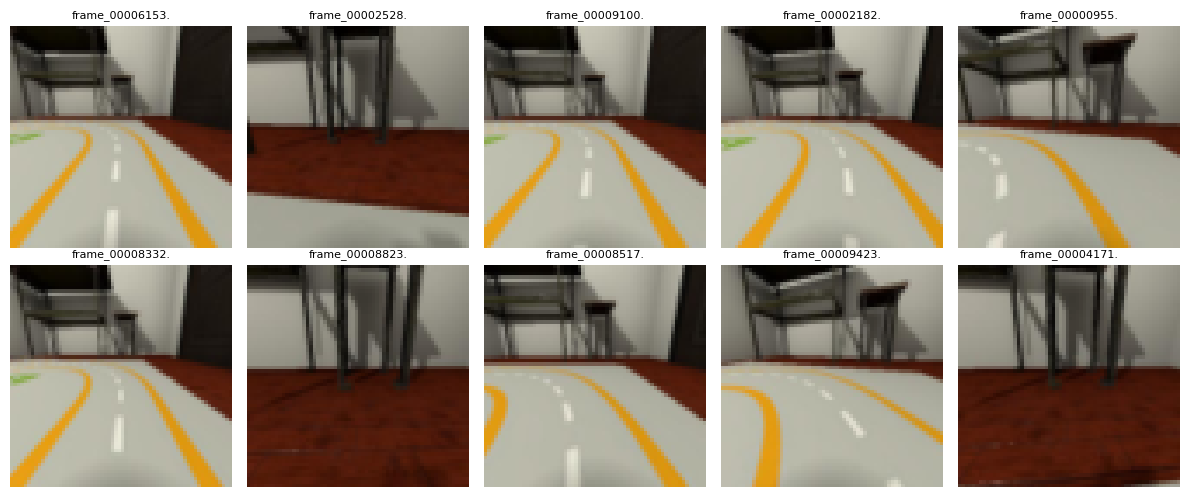


Direct loading of eval_real npy files:


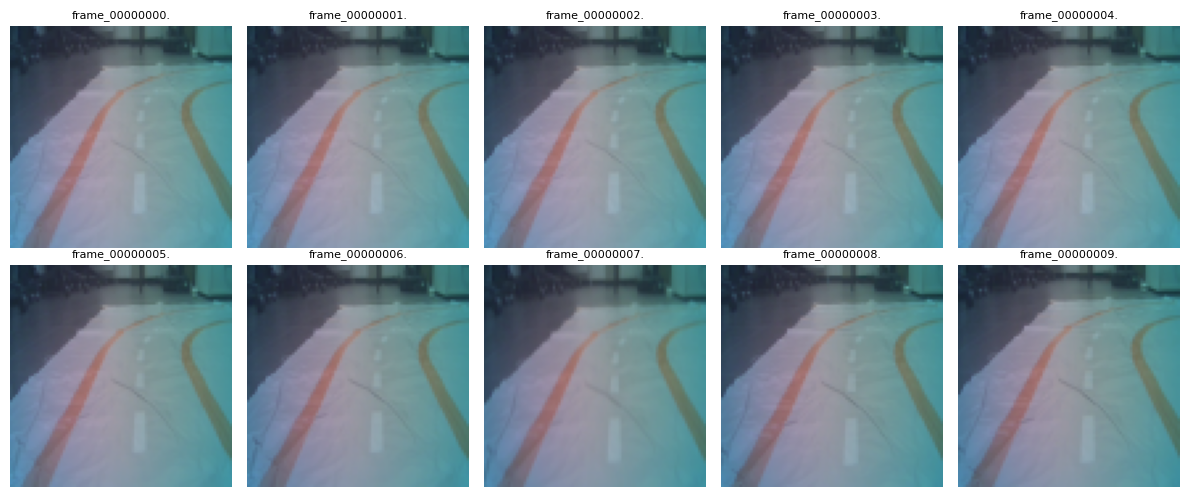

In [27]:
# Show example of images from validation dataset
import matplotlib.pyplot as plt
import numpy as np

# Inverse transform to denormalize and convert back to displayable format
inv_transform = transforms.Compose([
    # denormalize from [-1, 1] to [0, 1]
    transforms.Lambda(lambda x: (x * 0.5) + 0.5),
    transforms.ToPILImage(),
])

# Show images in 2*5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Display images from validation dataset
for i in range(min(10, len(val_dataset))):
    image = val_dataset[i]
    img = inv_transform(image)
    axes[i].imshow(img)
    axes[i].axis('off')
    # Show which file this is (from val_img_paths)
    filename = os.path.basename(val_img_paths[i])
    axes[i].set_title(filename[:15], fontsize=8)

plt.tight_layout()
plt.show()

# Also show some raw npy data directly (first 10 eval_real files)
print("\nDirect loading of eval_real npy files:")
fig2, axes2 = plt.subplots(2, 5, figsize=(12, 5))
axes2 = axes2.flatten()

eval_real_files = sorted(glob.glob(os.path.join(eval_real_dir, "*.npy")))[:10]
for i, npy_path in enumerate(eval_real_files):
    raw_data = np.load(npy_path)
    axes2[i].imshow(raw_data)
    axes2[i].axis('off')
    axes2[i].set_title(os.path.basename(npy_path)[:15], fontsize=8)

plt.tight_layout()
plt.show()



In [28]:
# Build Beta-VAE
from models.beta_vae import BetaVAE
from models.beta_tc_vae import BetaTCVAE
import torch

# Training epochs
epochs = 60

LOSS_TYPE = 'Cyclical'  # 'H', 'B', 'PID', 'Cyclical'
# PID controller parameters --- IGNORE ---
EXP_KLD_LOSS = 10
# H parameters --- IGNORE ---
BETA = 2
# B parameters --- IGNORE ---
GAMMA = 20
MAX_CAPACITY = 400
# Cyclical parameters
TOTAL_STEPS = epochs * len(train_loader)
MAX_BETA = 4
RATIO = 0.5
MODE = 'linear'  # 'linear' or 'sigmoid'

# loss weights
ENABLE_PERCEPTUAL_LOSS = False
LPIPS_WEIGHT = 1.2

TVL_WEIGHT = 1e-3

# Define hidden dimensions
HIDDEN_DIMS = [32, 64, 128, 256, 512]

MODEL_NAME = "beta_tc_vae"
# MODEL_NAME = "beta_vae"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 128

if MODEL_NAME == "beta_tc_vae":
    # Arg set for Beta-TC-VAE
    ANNEAL_STEPS = 200
    ALPHA = 1
    BETA = 10
    GAMMA = 1

    model = BetaTCVAE(in_channels=3, latent_dim=LATENT_DIM,
                      hidden_dims=HIDDEN_DIMS.copy(), anneal_steps=ANNEAL_STEPS, alpha=ALPHA, beta=BETA, gamma=GAMMA,
                      enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                      lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT)
else:
    model = BetaVAE(in_channels=3, loss_type=LOSS_TYPE, gamma=GAMMA, latent_dim=LATENT_DIM,
                    hidden_dims=HIDDEN_DIMS.copy(), image_size=IMG_SIZE,
                    beta=BETA, max_capacity=MAX_CAPACITY, exp_kld_loss=EXP_KLD_LOSS, enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                    lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT,
                    total_steps=TOTAL_STEPS, max_beta=MAX_BETA, ratio=RATIO, circular_mode=MODE)
model.to(device)

BetaTCVAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (4): Seq

In [29]:
# Training a VAE on CelebA
import logging
import os
import torch
from models.base import BaseVAE
from torchvision.utils import save_image
from tqdm import tqdm
from typing import Dict
# import defaultdict
from collections import defaultdict


def train(model: BaseVAE, train_loader, optimizer, epoch, device):
    model.train()

    epoch_loss_dict = defaultdict(float)

    loop = tqdm(train_loader, desc=f'Train Epoch {epoch}')

    for batch_idx, data in enumerate(loop):
        data = data.to(device)

        optimizer.zero_grad()

        res = model.forward(data)

        loss_dict = model.loss_function(
            *res, M_N=data.size(0)/len(train_loader.dataset), is_val=False)

        loss = loss_dict['loss']
        loss.backward()
        optimizer.step()

        for k, v in loss_dict.items():
            epoch_loss_dict[k] += v.item()

    for k in epoch_loss_dict.keys():
        epoch_loss_dict[k] /= len(train_loader)

    return epoch_loss_dict


def validate(model: BaseVAE, val_loader, epoch, device, result_dir: str, train_data_len: float):
    model.eval()  # 切换到评估模式 (关闭 Dropout/BatchNum 统计更新)

    epoch_loss_dict = defaultdict(float)

    loop = tqdm(val_loader, desc=f'Validation Epoch {epoch}')
    with torch.no_grad():  # 验证阶段不需要计算梯度，节省显存
        for batch_idx, data in enumerate(loop):
            data = data.to(device)

            # 1. 前向传播
            res = model.forward(data)

            # 2. 计算 Loss (必须和训练时的 Loss 函数一致)
            # 这里的 M_N 相当于 beta-VAE 里的 beta
            kld_weight = data.size(0)/train_data_len
            loss_dict = model.loss_function(*res, M_N=kld_weight, is_val=True)

            for k, v in loss_dict.items():
                epoch_loss_dict[k] += v.item()

            # 3. 可视化 (只在第一个 Batch 做，避免存太多图)
            if batch_idx == 0:
                # 比较：原图 vs 重构图
                # n=8 表示显示前8张。cat 把原图和重构图上下拼起来
                recons = res[0]
                comparison = torch.cat([data[:8], recons[:8]])
                save_image(comparison.cpu(
                ), f'{result_dir}/reconstruction_{epoch}.png', nrow=8, normalize=True)

    for k in epoch_loss_dict.keys():
        epoch_loss_dict[k] /= len(val_loader)

    # Random sampling
    with torch.no_grad():
        z = torch.randn(8, model.latent_dim).to(device)
        sample = model.decode(z)
        save_image(
            sample.cpu(), f'{result_dir}/sample_{epoch}.png', nrow=8, normalize=True)

    return epoch_loss_dict

In [30]:
# Training model
import os
import json
from torch import optim
import logging
# Scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch


optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5)

train_losses = []

val_losses = []


best_recon_loss = float('inf')
no_improvement = 0
early_stopping_patience = 10
early_epoch = 10

# create results directory
result_dir = f"results_{MODEL_NAME}_ImSize{IMG_SIZE[0]}_Lat{LATENT_DIM}"
if ENABLE_PERCEPTUAL_LOSS:
    result_dir += f"_TVL{int(TVL_WEIGHT*1e4)}_LPIPS{int(LPIPS_WEIGHT*10)}"

if MODEL_NAME == "beta_tc_vae":
    result_dir += f"_Alpha{ALPHA}_Beta{BETA}_Gamma{GAMMA}"
else:
    result_dir += f"_{LOSS_TYPE}"
    if LOSS_TYPE == 'H':
        result_dir += f"_Beta{BETA}"
    elif LOSS_TYPE == 'B':
        result_dir += f"_G{GAMMA}_C{MAX_CAPACITY}"
    elif LOSS_TYPE == 'PID':
        result_dir += f"_EXP{EXP_KLD_LOSS}"
    elif LOSS_TYPE == 'Cyclical':
        result_dir += f"_MaxBeta{MAX_BETA}_Ratio{int(RATIO*100)}_{MODE}"
os.makedirs(result_dir, exist_ok=True)

# write all hyperparameters to a json file
# using lowercase keys
with open(f"{result_dir}/hyperparameters.json", "w") as f:
    hyperparams = {
        "model_name": MODEL_NAME,
        "image_size": IMG_SIZE[0],
        "latent_dim": LATENT_DIM,
        "loss_type": LOSS_TYPE,
        "beta": BETA,
        "gamma": GAMMA,
        "max_capacity": MAX_CAPACITY,
        "exp_kld_loss": EXP_KLD_LOSS,
        "total_steps": TOTAL_STEPS,
        "max_beta": MAX_BETA,
        "ratio": RATIO,
        "circular_mode": MODE,
        "enable_perceptual_loss": ENABLE_PERCEPTUAL_LOSS,
        "lpips_weight": LPIPS_WEIGHT,
        "tvl_weight": TVL_WEIGHT,
        "epochs": epochs,
        "batch_size": BATCH_SIZE,
        "hidden_dims": HIDDEN_DIMS,
        "alpha": ALPHA,
        "anneal_steps": ANNEAL_STEPS,
        # Add more hyperparameters as needed
    }
    json.dump(hyperparams, f, indent=4)

start_epoch = 0

# Load existing model if any
model_path = f"{result_dir}/last_{MODEL_NAME}.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    # get the epoch from samples images names
    sample_files = [f for f in os.listdir(
        result_dir) if f.startswith("sample_") and f.endswith(".png")]
    if sample_files:
        sample_epochs = [int(f.split("_")[1].split(".")[0])
                         for f in sample_files]
        start_epoch = max(sample_epochs) + 1
    logging.info(f"Loaded existing model from {model_path}")

logging.basicConfig(level=logging.INFO)
logging.info("Training started")


for epoch in range(start_epoch, epochs):
    train_loss_dict = train(model, train_loader, optimizer, epoch, device)
    train_losses.append(train_loss_dict)

    logging.info(f"Epoch {epoch}, Train BCE Loss: {train_loss_dict["Reconstruction_Loss"]:.4f}, \
                 Train KLD Loss: {train_loss_dict["KLD_Loss"]:.4f}, Train Loss: {train_loss_dict["loss"]:.4f}")

    val_loss_dict = validate(model, val_loader, epoch,
                             device, result_dir, len(train_dataset))
    val_losses.append(val_loss_dict)

    logging.info(f"Epoch {epoch}, Val BCE Loss: {val_loss_dict["Reconstruction_Loss"]:.4f},\
                  Val KLD Loss: {val_loss_dict["KLD_Loss"]:.4f}, Val Loss: {val_loss_dict["loss"]:.4f}")

    if epoch < early_epoch:
        continue
    recon_loss = val_loss_dict["Reconstruction_Loss"]
    if recon_loss < best_recon_loss:
        best_recon_loss = recon_loss
        no_improvement = 0
        # save model
        torch.save(model.state_dict(), f"{result_dir}/best_{MODEL_NAME}.pth")
    else:
        no_improvement += 1
        if no_improvement >= early_stopping_patience:
            logging.info(f"Early stopping at epoch {epoch}")
            break

# save model
torch.save(model.state_dict(), f"{result_dir}/last_{MODEL_NAME}.pth")

logging.info(f"Training Finished")

INFO:root:Training started
Train Epoch 0: 100%|██████████| 9/9 [00:01<00:00,  6.92it/s]
INFO:root:Epoch 0, Train BCE Loss: 1149521.1736,                  Train KLD Loss: 392.5070, Train Loss: -3666.4948
Validation Epoch 0: 100%|██████████| 2/2 [00:00<00:00, 14.24it/s]
INFO:root:Epoch 0, Val BCE Loss: 631609.4492,                  Val KLD Loss: 105.1662, Val Loss: -4086.0193
Train Epoch 1: 100%|██████████| 9/9 [00:01<00:00,  6.85it/s]
INFO:root:Epoch 1, Train BCE Loss: 757262.6424,                  Train KLD Loss: 395.4611, Train Loss: -4674.1842
Validation Epoch 1: 100%|██████████| 2/2 [00:00<00:00, 14.09it/s]
INFO:root:Epoch 1, Val BCE Loss: 500780.8711,                  Val KLD Loss: 82.5616, Val Loss: -4360.1306
Train Epoch 2: 100%|██████████| 9/9 [00:01<00:00,  6.84it/s]
INFO:root:Epoch 2, Train BCE Loss: 657309.8993,                  Train KLD Loss: 62.9590, Train Loss: -4926.0766
Validation Epoch 2: 100%|██████████| 2/2 [00:00<00:00, 14.46it/s]
INFO:root:Epoch 2, Val BCE Loss: 37

In [31]:
# save training and validation losses
import pandas as pd
# save training and validation losses
train_loss_df = pd.DataFrame(train_losses[1:])
val_loss_df = pd.DataFrame(val_losses[1:])
train_loss_df.to_csv(f"{result_dir}/train_losses.csv", index=False)
val_loss_df.to_csv(f"{result_dir}/val_losses.csv", index=False)

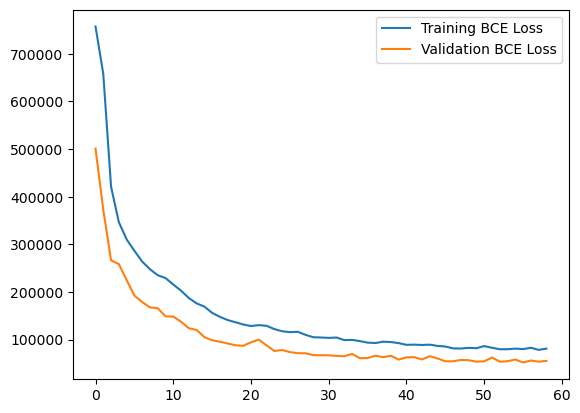

In [32]:
# Visulization Losses
import matplotlib.pyplot as plt
# draw train and val Reconstruction Loss
plt.plot([loss_dict["Reconstruction_Loss"]
         for loss_dict in train_losses[1:]], label='Training BCE Loss')
plt.plot([loss_dict["Reconstruction_Loss"]
         for loss_dict in val_losses[1:]], label='Validation BCE Loss')

plt.legend()
plt.savefig(f"{result_dir}/recon_loss_curve.png")
plt.show()

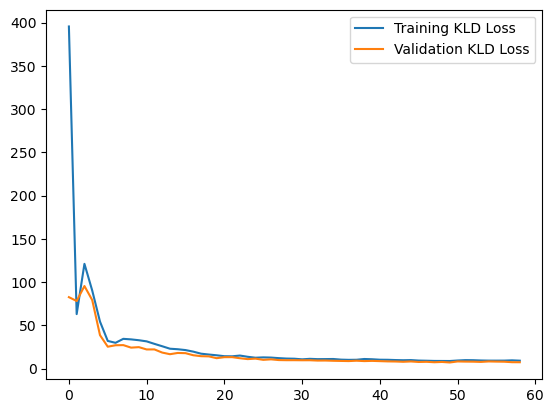

In [33]:
# draw train and val KLD Loss
plt.plot([loss_dict["KLD_Loss"]
         for loss_dict in train_losses[1:]], label='Training KLD Loss')
plt.plot([loss_dict["KLD_Loss"]
         for loss_dict in val_losses[1:]], label='Validation KLD Loss')
plt.legend()
# save figure
plt.savefig(f"{result_dir}/kld_loss_curve.png")
plt.show()

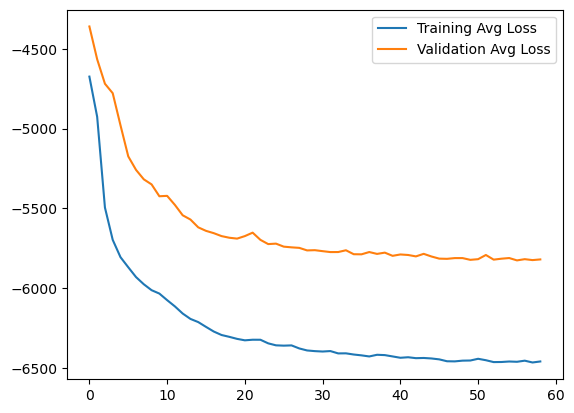

In [34]:
# draw train and val loss
plt.plot([loss_dict["loss"]
         for loss_dict in train_losses[1:]], label='Training Avg Loss')
plt.plot([loss_dict["loss"]
         for loss_dict in val_losses[1:]], label='Validation Avg Loss')

plt.legend()
# save figure
plt.savefig(f"{result_dir}/loss_curve.png")
plt.show()

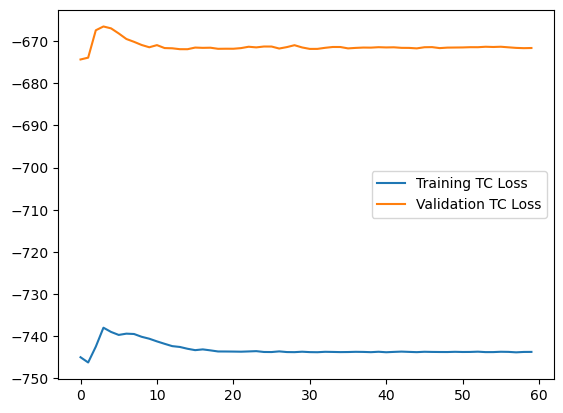

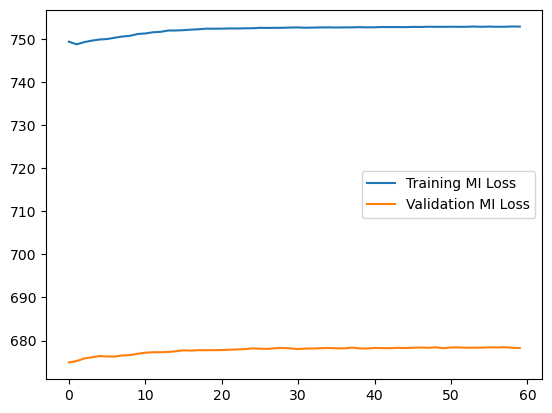

In [35]:
# if exists TC_Loss and MI_Loss, draw them

if MODEL_NAME == "beta_tc_vae":
    # draw TC Loss
    plt.plot([loss_dict["TC_Loss"]
             for loss_dict in train_losses], label='Training TC Loss')
    plt.plot([loss_dict["TC_Loss"]
             for loss_dict in val_losses], label='Validation TC Loss')
    plt.legend()
    plt.savefig(f"{result_dir}/tc_loss_curve.png")
    plt.show()

    # draw MI Loss
    plt.plot([loss_dict["MI_Loss"]
             for loss_dict in train_losses], label='Training MI Loss')
    plt.plot([loss_dict["MI_Loss"]
             for loss_dict in val_losses], label='Validation MI Loss')
    plt.legend()
    plt.savefig(f"{result_dir}/mi_loss_curve.png")
    plt.show()

In [ ]:
# test reconstruction pure real data


In [ ]:
# Test reconstruction on eval_real data
import torch
import os
import glob
import json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from my_dataset import CustomImageDataset
from models.beta_vae import BetaVAE
from models.beta_tc_vae import BetaTCVAE
import numpy as np

# Load model (update result_dir if needed)
# result_dir should be set from training cell
if 'result_dir' not in locals() or result_dir is None:
    # Try to find the most recent result directory
    result_dirs = [d for d in os.listdir('.') if d.startswith('results_') and os.path.isdir(d)]
    if result_dirs:
        result_dir = max(result_dirs, key=os.path.getmtime)
        print(f"Using result_dir: {result_dir}")
    else:
        raise ValueError("No result directory found. Please train the model first or set result_dir manually.")

# Load hyperparameters from json file
hyperparams_path = os.path.join(result_dir, 'hyperparameters.json')
if os.path.exists(hyperparams_path):
    with open(hyperparams_path, 'r') as f:
        hyperparams = json.load(f)
    print(f"Loaded hyperparameters from {hyperparams_path}")
    # Extract parameters
    MODEL_NAME = hyperparams.get('model_name', 'beta_vae')
    IMG_SIZE = (hyperparams.get('image_size', 64), hyperparams.get('image_size', 64))
    LATENT_DIM = hyperparams.get('latent_dim', 128)
    HIDDEN_DIMS = hyperparams.get('hidden_dims', [32, 64, 128, 256, 512])
    LOSS_TYPE = hyperparams.get('loss_type', 'H')
    BETA = hyperparams.get('beta', 1)
    GAMMA = hyperparams.get('gamma', 20)
    MAX_CAPACITY = hyperparams.get('max_capacity', 400)
    EXP_KLD_LOSS = hyperparams.get('exp_kld_loss', 10)
    ENABLE_PERCEPTUAL_LOSS = hyperparams.get('enable_perceptual_loss', False)
    LPIPS_WEIGHT = hyperparams.get('lpips_weight', 1.2)
    TVL_WEIGHT = hyperparams.get('tvl_weight', 1e-3)
    MAX_BETA = hyperparams.get('max_beta', 4)
    RATIO = hyperparams.get('ratio', 0.5)
    MODE = hyperparams.get('circular_mode', 'linear')
    TOTAL_STEPS = hyperparams.get('total_steps', 10000)
    ALPHA = hyperparams.get('alpha', 1)
    ANNEAL_STEPS = hyperparams.get('anneal_steps', 200)
else:
    print("Warning: hyperparameters.json not found. Using default values or values from previous cells.")
    # Use default values if not in locals
    if 'MODEL_NAME' not in locals():
        MODEL_NAME = 'beta_vae'
    if 'IMG_SIZE' not in locals():
        IMG_SIZE = (64, 64)
    if 'LATENT_DIM' not in locals():
        LATENT_DIM = 128

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load eval_real data
eval_real_dir = "data/road_track/eval_real"
eval_real_files = sorted(glob.glob(os.path.join(eval_real_dir, "*.npy")))
print(f"Found {len(eval_real_files)} eval_real files")

# Use the same transform as training
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

eval_real_dataset = CustomImageDataset(eval_real_files, transform=transform)
eval_real_loader = DataLoader(eval_real_dataset, batch_size=16, shuffle=False)

# Load model
model_path = os.path.join(result_dir, f"best_{MODEL_NAME}.pth")
if not os.path.exists(model_path):
    model_path = os.path.join(result_dir, f"last_{MODEL_NAME}.pth")
    
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found in {result_dir}")

print(f"Loading model from: {model_path}")

# Create model based on MODEL_NAME
if MODEL_NAME == "beta_tc_vae":
    model = BetaTCVAE(in_channels=3, latent_dim=LATENT_DIM,
                      hidden_dims=HIDDEN_DIMS.copy(), anneal_steps=ANNEAL_STEPS, 
                      alpha=ALPHA, beta=BETA, gamma=GAMMA,
                      enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                      lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT)
else:
    model = BetaVAE(in_channels=3, loss_type=LOSS_TYPE, gamma=GAMMA, latent_dim=LATENT_DIM,
                    hidden_dims=HIDDEN_DIMS.copy(), image_size=IMG_SIZE,
                    beta=BETA, max_capacity=MAX_CAPACITY, exp_kld_loss=EXP_KLD_LOSS, 
                    enable_perceptual_loss=ENABLE_PERCEPTUAL_LOSS,
                    lpips_weight=LPIPS_WEIGHT, tvl_weight=TVL_WEIGHT,
                    total_steps=TOTAL_STEPS, max_beta=MAX_BETA, ratio=RATIO, circular_mode=MODE)

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")

# Test reconstruction on eval_real data
num_samples = min(16, len(eval_real_dataset))
with torch.no_grad():
    # Get a batch of eval_real data
    data = next(iter(eval_real_loader))[:num_samples].to(device)
    
    # Reconstruct
    res = model.forward(data)
    recons = res[0]
    
    # Calculate loss
    kld_weight = data.size(0) / len(eval_real_dataset)
    loss_dict = model.loss_function(*res, M_N=kld_weight, is_val=True)
    
    print("\nReconstruction results on eval_real data:")
    for k, v in loss_dict.items():
        print(f"  {k}: {v.item():.4f}")

# Save reconstruction comparison
comparison = torch.cat([data[:num_samples], recons[:num_samples]])
save_path = os.path.join(result_dir, 'eval_real_reconstruction.png')
save_image(comparison.cpu(), save_path, nrow=num_samples, normalize=True)
print(f"\nReconstruction comparison saved to: {save_path}")

# Display images
inv_transform = transforms.Compose([
    transforms.Lambda(lambda x: (x * 0.5) + 0.5),
    transforms.ToPILImage(),
])

fig, axes = plt.subplots(2, num_samples, figsize=(num_samples*2, 4))
for i in range(num_samples):
    # Original
    img_orig = inv_transform(data[i].cpu())
    axes[0, i].imshow(img_orig)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original {i+1}', fontsize=8)
    
    # Reconstructed
    img_recon = inv_transform(recons[i].cpu())
    axes[1, i].imshow(img_recon)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Recon {i+1}', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(result_dir, 'eval_real_reconstruction_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Evaluation complete!")
